NameError: name 'textstr' is not defined

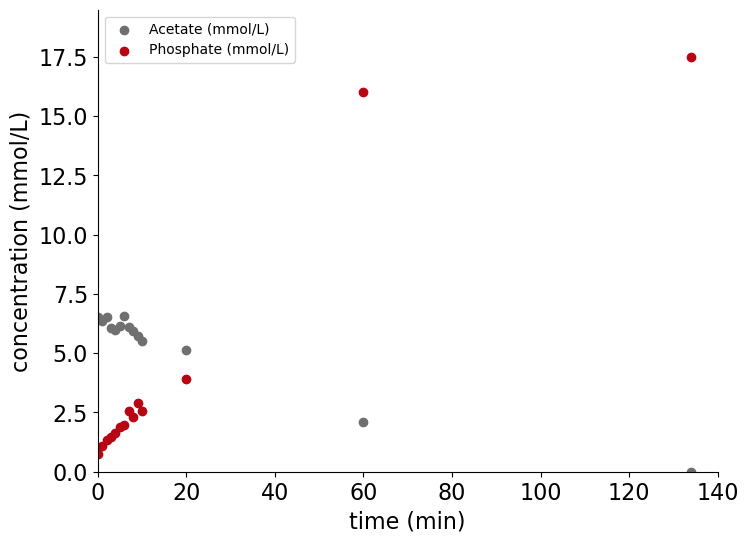

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Data
time_hours = np.array([0.00, 0.0167, 0.0333, 0.05, 0.0667, 0.0833, 0.10, 0.1167, 0.1333, 0.15, 0.1667, 0.3333, 1.00, 2.2333])
acetate = np.array([6.508865, 6.354757, 6.517522, 6.065590, 5.991134, 6.145241, 6.555616, 6.095026, 5.916677, 5.736597, 5.501107, 5.142678, 2.081313, 0.000000])
phosphate = np.array([0.750157, 1.105552, 1.353451, 1.480055, 1.641954, 1.888584, 1.987832, 2.568246, 2.287478, 2.895362, 2.576307, 3.890418, 15.999945, 17.487935])

# Select data for regression (time between 0 and 0.33 hours)
time_subset = time_hours[time_hours <= 0.3333]
acetate_subset = acetate[:len(time_subset)]
phosphate_subset = phosphate[:len(time_subset)]

# Linear regression for acetate consumption rate
slope_ac, _, _, _, _ = linregress(time_subset, acetate_subset)
qAc = slope_ac / 8.09597327096146  # Specific acetate consumption rate

# Linear regression for phosphate release rate
slope_pi, _, _, _, _ = linregress(time_subset, phosphate_subset)
qPi = slope_pi / 8.09597327096146  # Specific phosphate releasing rate

# Convert time to minutes
time_minutes = time_hours * 60

time_subset_minutes = time_subset * 60

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(time_minutes, acetate, color='#717070', label='Acetate (mmol/L)')
ax.scatter(time_minutes, phosphate, color='#b80513', label='Phosphate (mmol/L)')

# Labels and limits
ax.set_xlabel("time (min)", fontsize=16)
ax.set_ylabel("concentration (mmol/L)", fontsize=16)

ax.tick_params(axis='x', labelsize=16)  # X-axis tick labels font size
ax.tick_params(axis='y', labelsize=16)  # Y-axis tick labels font size

ax.set_xlim(0, 140)
ax.set_ylim(0, max(max(acetate), max(phosphate)) + 2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()

textstr = f"q$_{{Ac}}$ = {qAc:.2f} mmol/g$^{{CDW}}$/h\nq$_{{Pi}}$ = {qPi:.2f} mmol/g$^{{CDW}}$/h "

# Add textbox with rates
text_x, text_y = 85, 5  # Allow manual control
ax.text(text_x, text_y, textstr, fontsize=12, bbox=dict(facecolor='#FFFFE0', edgecolor='white', boxstyle='round,pad=0.5'))

# Add inset
inset_x, inset_y = "80%", "80%"  # Allow manual control
inset_x_pos, inset_y_pos = 0.65, 0.4  # Allow manual control over position
ax_inset = inset_axes(ax, width=inset_x, height=inset_y, bbox_to_anchor=(inset_x_pos, inset_y_pos, 0.3, 0.3), bbox_transform=ax.transAxes)  # Control position with loc parameter
ax_inset.scatter(time_subset_minutes, acetate_subset, color='#717070')
ax_inset.scatter(time_subset_minutes, phosphate_subset, color='#b80513')
ax_inset.set_xlim(min(time_subset_minutes), max(time_subset_minutes)+1)
ax_inset.set_ylim(min(min(acetate_subset), min(phosphate_subset)), max(max(acetate_subset), max(phosphate_subset))+1)
#ax_inset.set_xticks([])
#ax_inset.set_yticks([])
# Set font size for tick labels on the inset plot
ax_inset.tick_params(axis='x', labelsize=12)
ax_inset.tick_params(axis='y', labelsize=12)

# Save the figure
plt.savefig("Acetate_Phosphate_during_labeling.tiff", format='tiff', dpi=150)  # Control resolution with dpi parameter

plt.show()